BACKGROUND: 

The data is a marketing campaign data of a skin care clinic associated with its success.

Description of variables-

Success: Response to marketing campaign of Skin Care Clinic which offers both  products and services. (1: email Opened, 0: email not opened)

AGE: Age Group of Customer

Recency_Service: Number of days since last service purchase

Recency_Product: Number of days since last product purchase

Bill_Service: Total bill amount for service in last 3 months

Bill_Product: Total bill amount for products in last 3 months

Gender (1: Male, 2: Female)

  

Note: Answer following questions using entire data and do not create test data.




QUESTIONS-

 

Import Email Campaign data. Obtain decision tree to classify cases as success=0 or 1. Obtain Sensitivity/Recall using cut-off value as 0.50 for estimated probabilities. 
                                                           

Compare performance of Decision Tree and Random Forest Method using area under the ROC curve. 
 

Implement Neural Network Algorithm and obtain are under the ROC curve .

In [13]:
# ============================================================================
# DECISION TREE, RANDOM FOREST & NEURAL NETWORK ANALYSIS
# Using Full Dataset (No Train/Test Split as per requirements)
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    roc_curve, auc, classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
import joblib
import os
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Create directories
os.makedirs('models', exist_ok=True)
os.makedirs('reports/figures', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
os.chdir(r"C:\Users\willi\GitHub\ML2_Email_Campaign_PY\data\raw")


# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*80)
print("DECISION TREE, RANDOM FOREST & NEURAL NETWORK ANALYSIS")
print("="*80)
print("\n⚠️  NOTE: Using entire dataset as per assignment requirements")
print("   (No train/test split - metrics will be overly optimistic)\n")

# ============================================================================
# LOAD DATA
# ============================================================================

print("📊 Loading Data...")
print("-" * 80)

df = pd.read_csv('Email Campaign.csv')

print(f"✅ Data loaded successfully!")
print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   Response Rate: {df['Success'].mean()*100:.2f}%")
print(f"\nFirst 5 rows:")
print(df.head())

DECISION TREE, RANDOM FOREST & NEURAL NETWORK ANALYSIS

⚠️  NOTE: Using entire dataset as per assignment requirements
   (No train/test split - metrics will be overly optimistic)

📊 Loading Data...
--------------------------------------------------------------------------------
✅ Data loaded successfully!
   Shape: 683 rows × 8 columns
   Response Rate: 26.35%

First 5 rows:
   SN  Gender   AGE  Recency_Service  Recency_Product  Bill_Service  \
0   1       1  <=45               12               11         11.82   
1   2       2  <=30                6                0         10.31   
2   3       1  <=30                1                9          7.43   
3   4       1  <=45                2               14         13.68   
4   5       2  <=30                0               11          4.56   

   Bill_Product  Success  
0          2.68        0  
1          1.32        0  
2          0.49        0  
3          1.85        0  
4          1.01        1  


#### Step 2: Data Pre-Processing

In [14]:
# ============================================================================
# DATA PREPROCESSING
# ============================================================================

print("\n" + "="*80)
print("📊 Data Preprocessing")
print("="*80)

# Encode AGE variable
le = LabelEncoder()
df['AGE_Encoded'] = le.fit_transform(df['AGE'])

print("\n📋 Age Encoding Mapping:")
for i, age_group in enumerate(le.classes_):
    print(f"   {age_group} → {i}")

# Prepare features and target
X = df[['Gender', 'AGE_Encoded', 'Recency_Service', 'Recency_Product', 
        'Bill_Service', 'Bill_Product']]
y = df['Success']

# Standardize features (important for Neural Networks)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print(f"\n✅ Features prepared:")
print(f"   Original features: {X.shape}")
print(f"   Scaled features: {X_scaled.shape}")
print(f"   Target variable: {y.shape}")
print(f"   Class distribution: {y.value_counts().to_dict()}")




📊 Data Preprocessing

📋 Age Encoding Mapping:
   <=30 → 0
   <=45 → 1
   <=55 → 2

✅ Features prepared:
   Original features: (683, 6)
   Scaled features: (683, 6)
   Target variable: (683,)
   Class distribution: {0: 503, 1: 180}


### Step 3: Question 1 Deccision Tree Classifier


🌳 QUESTION 1: Decision Tree Classification

🔄 Training Decision Tree...
✅ Decision Tree trained successfully!
   Tree depth: 8
   Number of leaves: 42
   Number of features: 6

DECISION TREE PERFORMANCE (Cutoff = 0.50)

📊 Classification Report:
              precision    recall  f1-score   support

  Not Opened     0.8815    0.9165    0.8986       503
      Opened     0.7375    0.6556    0.6941       180

    accuracy                         0.8477       683
   macro avg     0.8095    0.7860    0.7964       683
weighted avg     0.8435    0.8477    0.8447       683


🎯 SENSITIVITY/RECALL (Success=1) at cutoff 0.50: 0.6556 (65.56%)
   → Out of all actual email openers, model correctly identifies 65.56%

📈 Additional Metrics:
   Accuracy:  0.8477 (84.77%)
   Precision: 0.7375 (73.75%)
   F1-Score:  0.6941

📈 Additional Metrics:
   Accuracy:  0.8477 (84.77%)
   Precision: 0.7375 (73.75%)
   F1-Score:  0.6941

🔍 Feature Importance:
        Feature  Importance
   Bill_Service    0.400637
Re

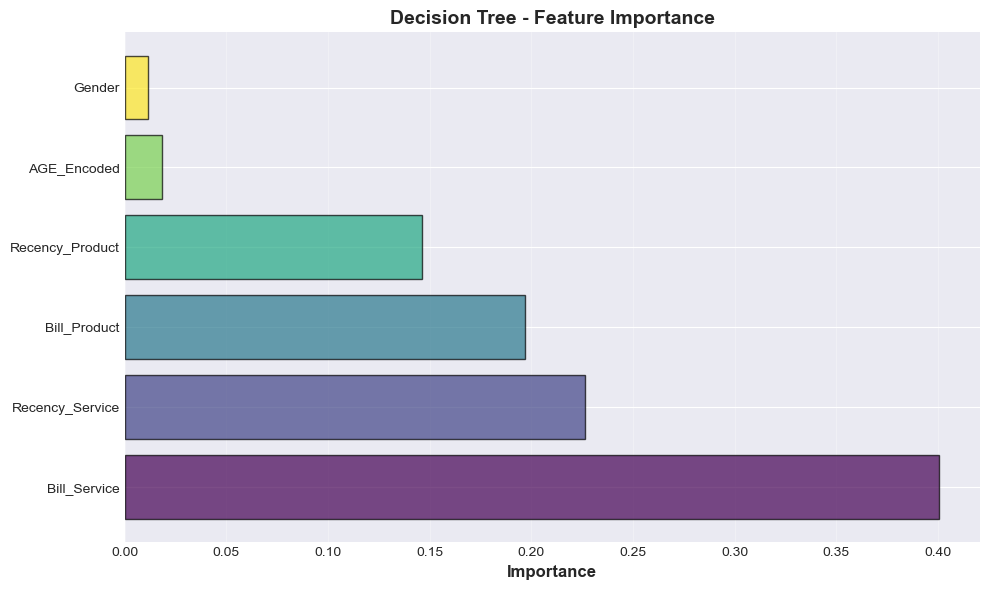

In [21]:
# ============================================================================
# QUESTION 1: DECISION TREE CLASSIFIER
# ============================================================================

print("\n" + "="*80)
print("🌳 QUESTION 1: Decision Tree Classification")
print("="*80)

# Train Decision Tree (using unscaled features - trees don't need scaling)
print("\n🔄 Training Decision Tree...")

dt_classifier = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,          # Limit depth to prevent overfitting
    min_samples_split=20,  # Minimum samples to split
    min_samples_leaf=10,   # Minimum samples in leaf
    random_state=42
)

dt_classifier.fit(X, y)

print("✅ Decision Tree trained successfully!")
print(f"   Tree depth: {dt_classifier.get_depth()}")
print(f"   Number of leaves: {dt_classifier.get_n_leaves()}")
print(f"   Number of features: {dt_classifier.n_features_in_}")

# Get predictions and probabilities
y_pred_dt = dt_classifier.predict(X)
y_prob_dt = dt_classifier.predict_proba(X)[:, 1]

# Apply 0.50 cutoff threshold (default, but explicit)
y_pred_dt_50 = (y_prob_dt >= 0.50).astype(int)

# Calculate metrics
print("\n" + "="*80)
print("DECISION TREE PERFORMANCE (Cutoff = 0.50)")
print("="*80)

print("\n📊 Classification Report:")
print(classification_report(y, y_pred_dt_50, 
                          target_names=['Not Opened', 'Opened'],
                          digits=4))

# Calculate ALL metrics for comparison
accuracy_dt = accuracy_score(y, y_pred_dt_50)
precision_dt = precision_score(y, y_pred_dt_50, pos_label=1)
recall_dt = recall_score(y, y_pred_dt_50, pos_label=1)  # ← Changed from 'sensitivity'
f1_dt = f1_score(y, y_pred_dt_50, pos_label=1)

# Display Sensitivity/Recall specifically
print(f"\n🎯 SENSITIVITY/RECALL (Success=1) at cutoff 0.50: {recall_dt:.4f} ({recall_dt*100:.2f}%)")
print(f"   → Out of all actual email openers, model correctly identifies {recall_dt*100:.2f}%")

print(f"\n📈 Additional Metrics:")
print(f"   Accuracy:  {accuracy_dt:.4f} ({accuracy_dt*100:.2f}%)")
print(f"   Precision: {precision_dt:.4f} ({precision_dt*100:.2f}%)")
print(f"   F1-Score:  {f1_dt:.4f}")
# Additional metrics
accuracy_dt = accuracy_score(y, y_pred_dt_50)
precision_dt = precision_score(y, y_pred_dt_50, pos_label=1)
f1_dt = f1_score(y, y_pred_dt_50, pos_label=1)

print(f"\n📈 Additional Metrics:")
print(f"   Accuracy:  {accuracy_dt:.4f} ({accuracy_dt*100:.2f}%)")
print(f"   Precision: {precision_dt:.4f} ({precision_dt*100:.2f}%)")
print(f"   F1-Score:  {f1_dt:.4f}")

# Feature Importance
print("\n🔍 Feature Importance:")
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_classifier.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.to_string(index=False))

# Visualize Feature Importance
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(feature_importance)))
bars = plt.barh(feature_importance['Feature'], feature_importance['Importance'], 
                color=colors, edgecolor='black', alpha=0.7)
plt.xlabel('Importance', fontweight='bold', fontsize=12)
plt.title('Decision Tree - Feature Importance', fontweight='bold', fontsize=14)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
print("\n✅ Feature importance plot saved: reports/figures/07_decision_tree_feature_importance.png")
plt.show()



### Step 4: Visualise Decsion Tree


📊 Visualizing Decision Tree Structure
✅ Decision tree structure saved: reports/figures/08_decision_tree_structure.png


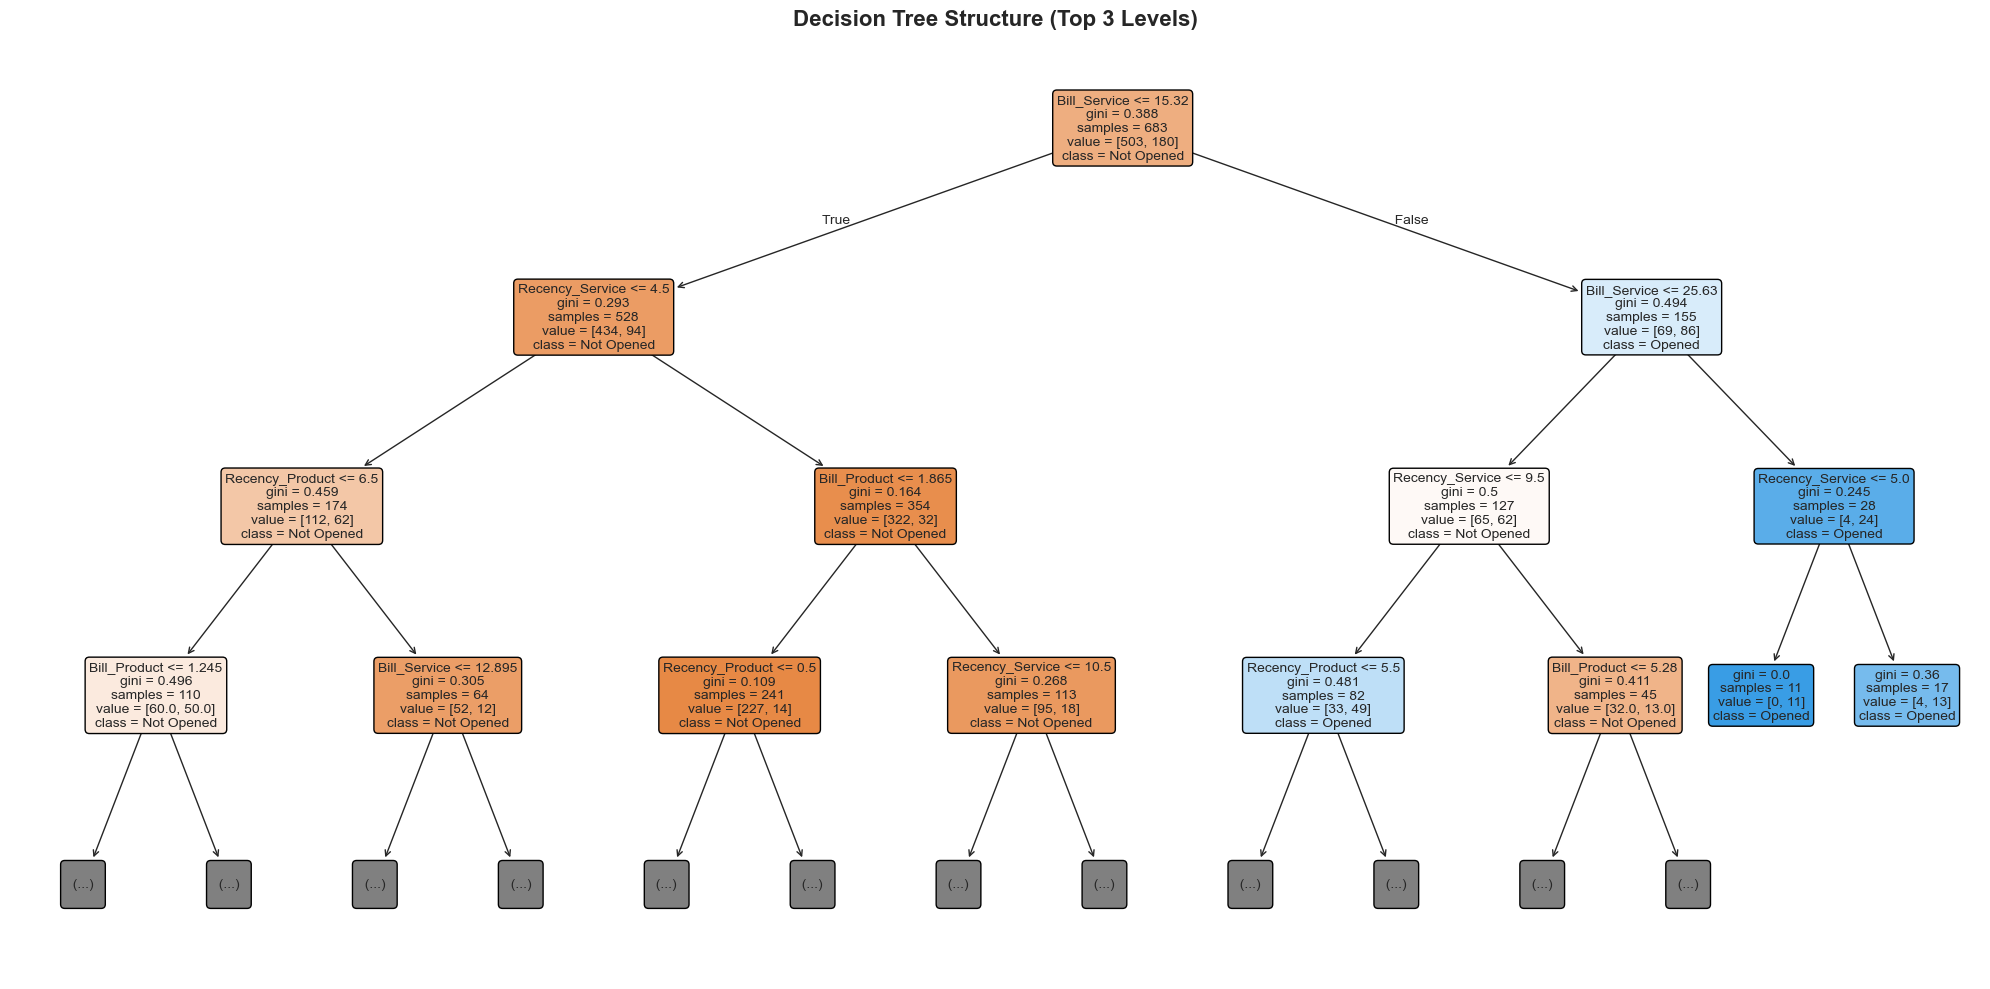

✅ Confusion matrix saved: reports/figures/09_decision_tree_confusion_matrix.png


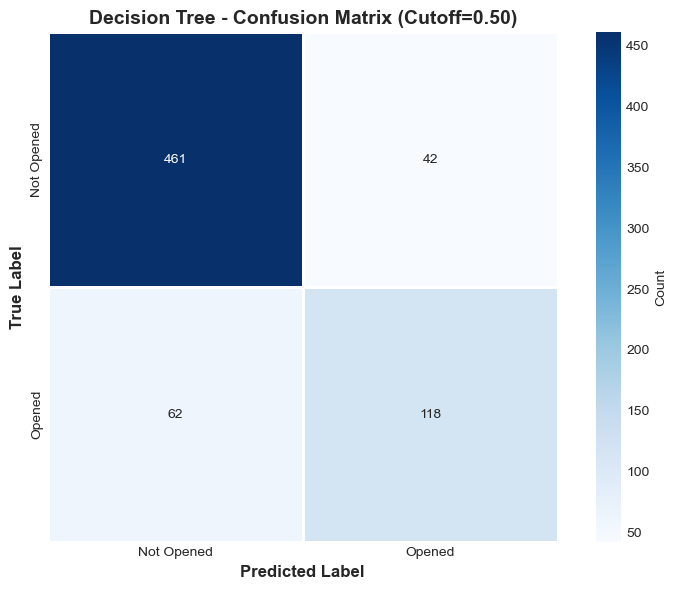

In [22]:
# ============================================================================
# VISUALIZE DECISION TREE STRUCTURE
# ============================================================================

print("\n" + "="*80)
print("📊 Visualizing Decision Tree Structure")
print("="*80)

# Plot the decision tree (first few levels for readability)
plt.figure(figsize=(20, 10))
plot_tree(dt_classifier, 
          max_depth=3,  # Show only top 3 levels for clarity
          feature_names=X.columns,
          class_names=['Not Opened', 'Opened'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Structure (Top 3 Levels)', fontweight='bold', fontsize=16)
plt.tight_layout()
print("✅ Decision tree structure saved: reports/figures/08_decision_tree_structure.png")
plt.show()

# Confusion Matrix
cm_dt = confusion_matrix(y, y_pred_dt_50)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Opened', 'Opened'],
            yticklabels=['Not Opened', 'Opened'],
            cbar_kws={'label': 'Count'}, square=True, linewidths=2)
plt.xlabel('Predicted Label', fontweight='bold', fontsize=12)
plt.ylabel('True Label', fontweight='bold', fontsize=12)
plt.title('Decision Tree - Confusion Matrix (Cutoff=0.50)', fontweight='bold', fontsize=14)
plt.tight_layout()
print("✅ Confusion matrix saved: reports/figures/09_decision_tree_confusion_matrix.png")
plt.show()

### Step 5: Question 2 - Random Forest Classifier


🌲 QUESTION 2: Random Forest Classification

🔄 Training Random Forest...
✅ Random Forest trained successfully!
   Number of trees: 100
   Max tree depth: 10
   Number of features: 6

RANDOM FOREST PERFORMANCE

📊 Classification Report:
              precision    recall  f1-score   support

  Not Opened     0.8513    0.9563    0.9007       503
      Opened     0.8136    0.5333    0.6443       180

    accuracy                         0.8448       683
   macro avg     0.8324    0.7448    0.7725       683
weighted avg     0.8414    0.8448    0.8332       683


📈 Performance Metrics:
   Accuracy:  0.8448 (84.48%)
   Precision: 0.8136 (81.36%)
   Recall:    0.5333 (53.33%)
   F1-Score:  0.6443

🔍 Random Forest Feature Importance:
        Feature  Importance
   Bill_Service    0.367358
Recency_Service    0.264759
   Bill_Product    0.191347
Recency_Product    0.114864
    AGE_Encoded    0.041654
         Gender    0.020018

✅ Feature importance plot saved: reports/figures/10_random_forest_fea

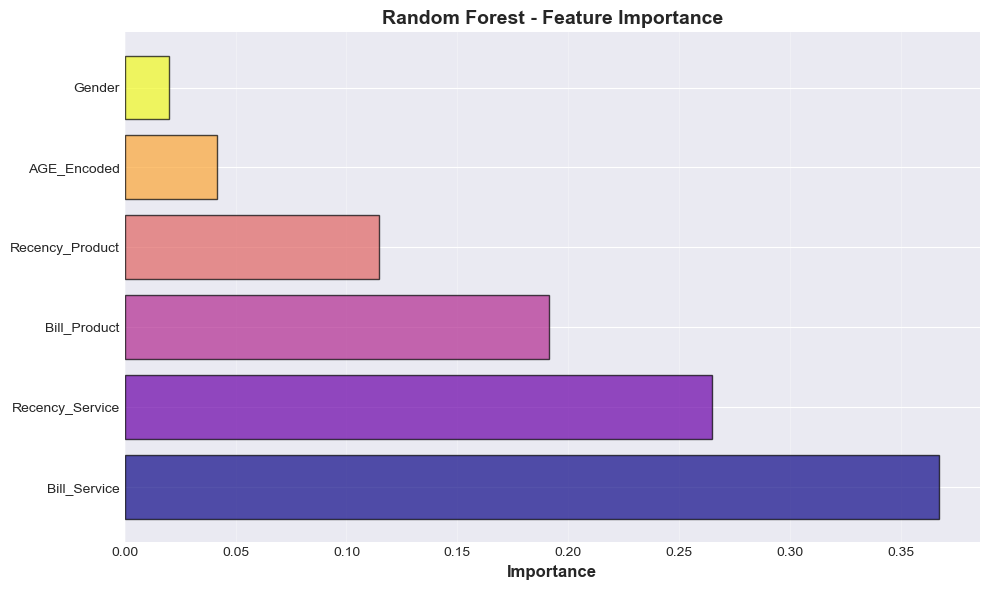

✅ Confusion matrix saved: reports/figures/11_random_forest_confusion_matrix.png


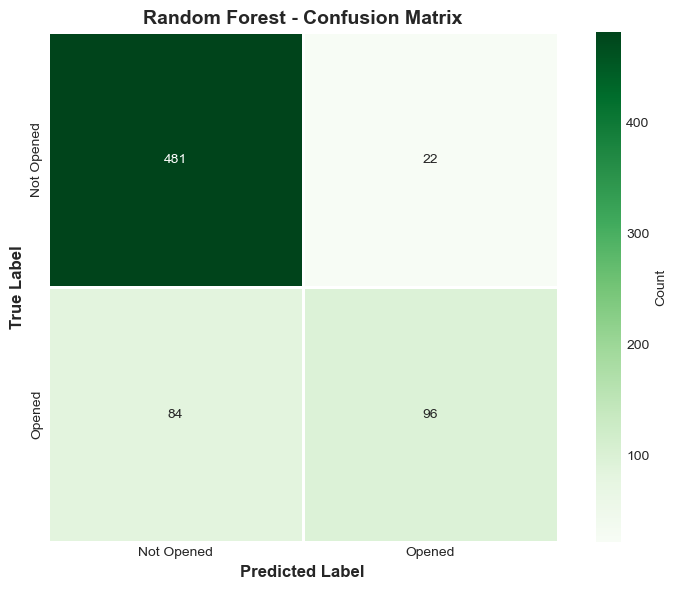

In [17]:
# ============================================================================
# QUESTION 2: RANDOM FOREST CLASSIFIER
# ============================================================================

print("\n" + "="*80)
print("🌲 QUESTION 2: Random Forest Classification")
print("="*80)

# Train Random Forest
print("\n🔄 Training Random Forest...")

rf_classifier = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    criterion='gini',
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',   # Number of features to consider at each split
    random_state=42,
    n_jobs=-1              # Use all CPU cores
)

rf_classifier.fit(X, y)

print("✅ Random Forest trained successfully!")
print(f"   Number of trees: {rf_classifier.n_estimators}")
print(f"   Max tree depth: {max([tree.get_depth() for tree in rf_classifier.estimators_])}")
print(f"   Number of features: {rf_classifier.n_features_in_}")

# Get predictions and probabilities
y_pred_rf = rf_classifier.predict(X)
y_prob_rf = rf_classifier.predict_proba(X)[:, 1]

# Calculate metrics
print("\n" + "="*80)
print("RANDOM FOREST PERFORMANCE")
print("="*80)

print("\n📊 Classification Report:")
print(classification_report(y, y_pred_rf, 
                          target_names=['Not Opened', 'Opened'],
                          digits=4))

# Metrics
accuracy_rf = accuracy_score(y, y_pred_rf)
precision_rf = precision_score(y, y_pred_rf, pos_label=1)
recall_rf = recall_score(y, y_pred_rf, pos_label=1)
f1_rf = f1_score(y, y_pred_rf, pos_label=1)

print(f"\n📈 Performance Metrics:")
print(f"   Accuracy:  {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")
print(f"   Precision: {precision_rf:.4f} ({precision_rf*100:.2f}%)")
print(f"   Recall:    {recall_rf:.4f} ({recall_rf*100:.2f}%)")
print(f"   F1-Score:  {f1_rf:.4f}")

# Feature Importance
print("\n🔍 Random Forest Feature Importance:")
rf_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_classifier.feature_importances_
}).sort_values('Importance', ascending=False)

print(rf_feature_importance.to_string(index=False))

# Visualize Feature Importance
plt.figure(figsize=(10, 6))
colors = plt.cm.plasma(np.linspace(0, 1, len(rf_feature_importance)))
bars = plt.barh(rf_feature_importance['Feature'], rf_feature_importance['Importance'], 
                color=colors, edgecolor='black', alpha=0.7)
plt.xlabel('Importance', fontweight='bold', fontsize=12)
plt.title('Random Forest - Feature Importance', fontweight='bold', fontsize=14)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
print("\n✅ Feature importance plot saved: reports/figures/10_random_forest_feature_importance.png")
plt.show()

# Confusion Matrix
cm_rf = confusion_matrix(y, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Not Opened', 'Opened'],
            yticklabels=['Not Opened', 'Opened'],
            cbar_kws={'label': 'Count'}, square=True, linewidths=2)
plt.xlabel('Predicted Label', fontweight='bold', fontsize=12)
plt.ylabel('True Label', fontweight='bold', fontsize=12)
plt.title('Random Forest - Confusion Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
print("✅ Confusion matrix saved: reports/figures/11_random_forest_confusion_matrix.png")
plt.show()



### STEP 6: ROC Curve Comparison - Decision Tree vs Random Forest


📊 ROC Curve Comparison: Decision Tree vs Random Forest

📈 Area Under ROC Curve (AUC):
   Decision Tree:  0.9140
   Random Forest:  0.9107
   Difference:     0.0033

🏆 Winner: Decision Tree (better by 0.33%)

✅ ROC curve comparison saved: reports/figures/12_roc_curve_dt_vs_rf.png


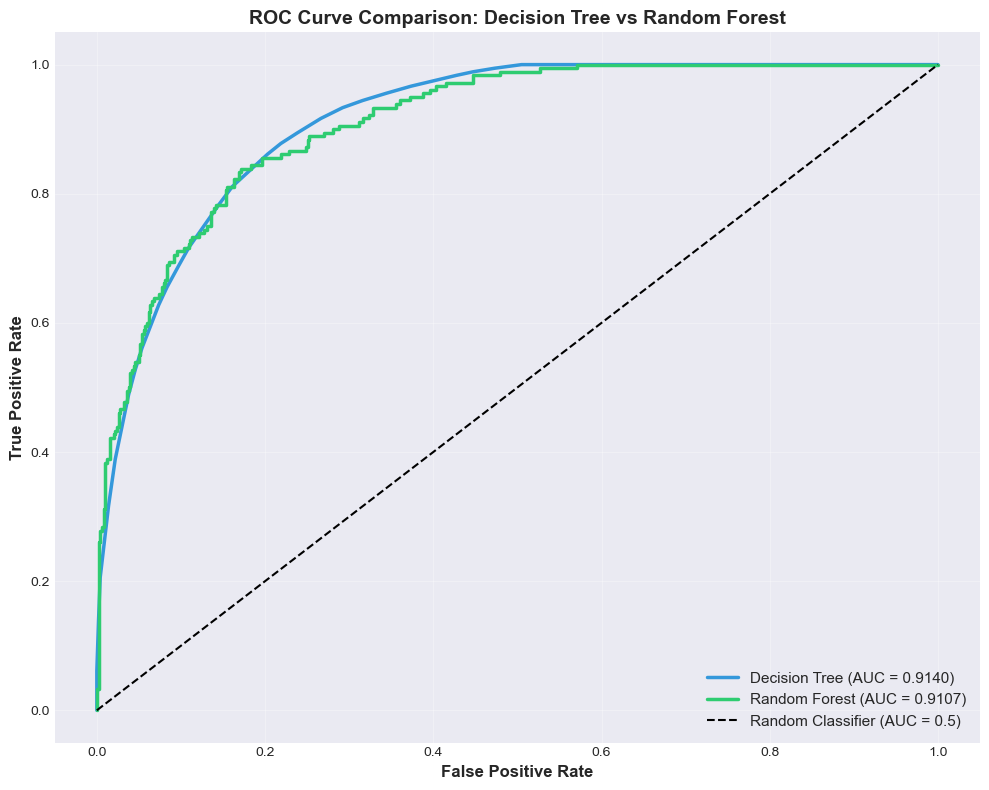

In [23]:
# ============================================================================
# ROC CURVE COMPARISON: DECISION TREE vs RANDOM FOREST
# ============================================================================

print("\n" + "="*80)
print("📊 ROC Curve Comparison: Decision Tree vs Random Forest")
print("="*80)

# Calculate ROC curves
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y, y_prob_dt)
auc_dt = auc(fpr_dt, tpr_dt)

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

print(f"\n📈 Area Under ROC Curve (AUC):")
print(f"   Decision Tree:  {auc_dt:.4f}")
print(f"   Random Forest:  {auc_rf:.4f}")
print(f"   Difference:     {abs(auc_rf - auc_dt):.4f}")

if auc_rf > auc_dt:
    print(f"\n🏆 Winner: Random Forest (better by {(auc_rf - auc_dt)*100:.2f}%)")
else:
    print(f"\n🏆 Winner: Decision Tree (better by {(auc_dt - auc_rf)*100:.2f}%)")

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.4f})', 
         linewidth=2.5, color='#3498db')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})', 
         linewidth=2.5, color='#2ecc71')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate', fontweight='bold', fontsize=12)
plt.ylabel('True Positive Rate', fontweight='bold', fontsize=12)
plt.title('ROC Curve Comparison: Decision Tree vs Random Forest', 
          fontweight='bold', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
print("\n✅ ROC curve comparison saved: reports/figures/12_roc_curve_dt_vs_rf.png")
plt.show()

### STEP 7: Question 3 - Neural Network Classifier


🧠 QUESTION 3: Neural Network Classification

🔄 Training Neural Network...
   Architecture: Input → Hidden(100) → Hidden(50) → Output
✅ Neural Network trained successfully!
   Number of iterations: 12
   Number of layers: 4
   Final loss: 0.426709

NEURAL NETWORK PERFORMANCE

📊 Classification Report:
              precision    recall  f1-score   support

  Not Opened     0.8167    0.8946    0.8539       503
      Opened     0.5985    0.4389    0.5064       180

    accuracy                         0.7745       683
   macro avg     0.7076    0.6668    0.6802       683
weighted avg     0.7592    0.7745    0.7623       683


📈 Performance Metrics:
   Accuracy:  0.7745 (77.45%)
   Precision: 0.5985 (59.85%)
   Recall:    0.4389 (43.89%)
   F1-Score:  0.5064

📈 Area Under ROC Curve (AUC): 0.7634

✅ Loss curve saved: reports/figures/13_neural_network_loss_curve.png


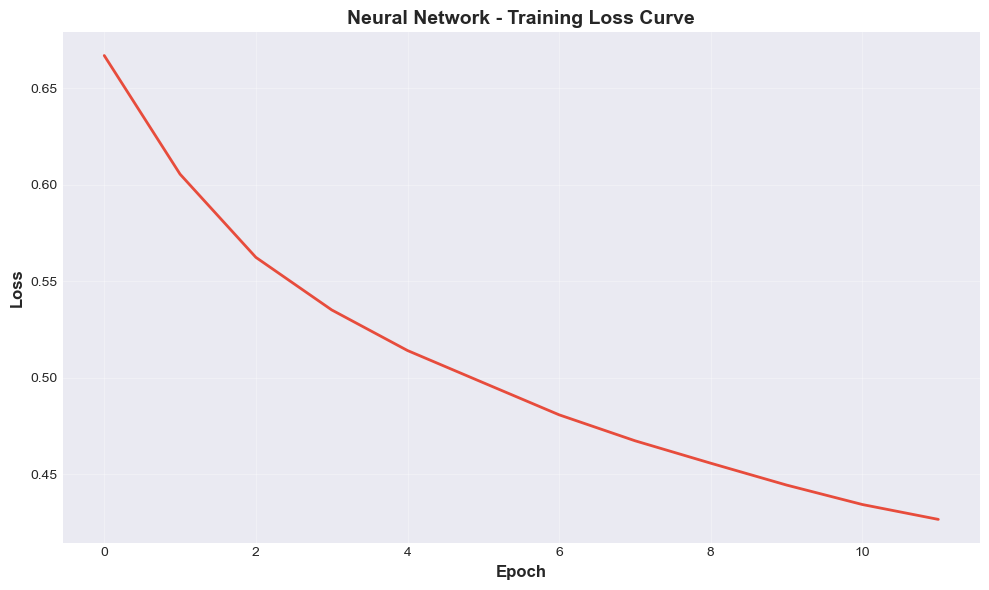

✅ Confusion matrix saved: reports/figures/14_neural_network_confusion_matrix.png


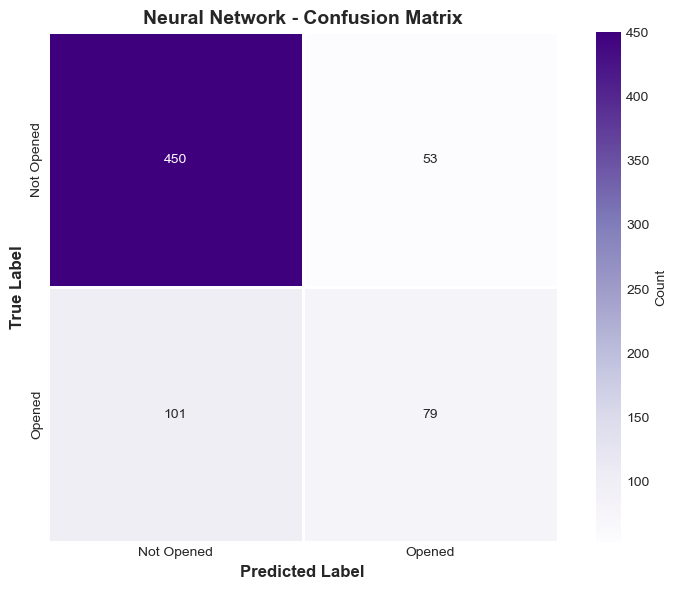

In [24]:
# ============================================================================
# QUESTION 3: NEURAL NETWORK (MLP) CLASSIFIER
# ============================================================================

print("\n" + "="*80)
print("🧠 QUESTION 3: Neural Network Classification")
print("="*80)

# Train Neural Network (using scaled features)
print("\n🔄 Training Neural Network...")
print("   Architecture: Input → Hidden(100) → Hidden(50) → Output")

nn_classifier = MLPClassifier(
    hidden_layer_sizes=(100, 50),  # Two hidden layers
    activation='relu',              # ReLU activation
    solver='adam',                  # Adam optimizer
    alpha=0.0001,                   # L2 regularization
    batch_size='auto',
    learning_rate='adaptive',       # Adaptive learning rate
    max_iter=500,                   # Maximum epochs
    random_state=42,
    early_stopping=True,            # Stop if no improvement
    validation_fraction=0.1,        # 10% for validation
    n_iter_no_change=10,           # Patience for early stopping
    verbose=False
)

nn_classifier.fit(X_scaled, y)

print("✅ Neural Network trained successfully!")
print(f"   Number of iterations: {nn_classifier.n_iter_}")
print(f"   Number of layers: {nn_classifier.n_layers_}")
print(f"   Final loss: {nn_classifier.loss_:.6f}")

# Get predictions and probabilities
y_pred_nn = nn_classifier.predict(X_scaled)
y_prob_nn = nn_classifier.predict_proba(X_scaled)[:, 1]

# Calculate metrics
print("\n" + "="*80)
print("NEURAL NETWORK PERFORMANCE")
print("="*80)

print("\n📊 Classification Report:")
print(classification_report(y, y_pred_nn, 
                          target_names=['Not Opened', 'Opened'],
                          digits=4))

# Metrics
accuracy_nn = accuracy_score(y, y_pred_nn)
precision_nn = precision_score(y, y_pred_nn, pos_label=1)
recall_nn = recall_score(y, y_pred_nn, pos_label=1)
f1_nn = f1_score(y, y_pred_nn, pos_label=1)

print(f"\n📈 Performance Metrics:")
print(f"   Accuracy:  {accuracy_nn:.4f} ({accuracy_nn*100:.2f}%)")
print(f"   Precision: {precision_nn:.4f} ({precision_nn*100:.2f}%)")
print(f"   Recall:    {recall_nn:.4f} ({recall_nn*100:.2f}%)")
print(f"   F1-Score:  {f1_nn:.4f}")

# Calculate ROC-AUC
fpr_nn, tpr_nn, thresholds_nn = roc_curve(y, y_prob_nn)
auc_nn = auc(fpr_nn, tpr_nn)

print(f"\n📈 Area Under ROC Curve (AUC): {auc_nn:.4f}")

# Training history (loss curve)
if hasattr(nn_classifier, 'loss_curve_'):
    plt.figure(figsize=(10, 6))
    plt.plot(nn_classifier.loss_curve_, linewidth=2, color='#e74c3c')
    plt.xlabel('Epoch', fontweight='bold', fontsize=12)
    plt.ylabel('Loss', fontweight='bold', fontsize=12)
    plt.title('Neural Network - Training Loss Curve', fontweight='bold', fontsize=14)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    print("\n✅ Loss curve saved: reports/figures/13_neural_network_loss_curve.png")
    plt.show()

# Confusion Matrix
cm_nn = confusion_matrix(y, y_pred_nn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Not Opened', 'Opened'],
            yticklabels=['Not Opened', 'Opened'],
            cbar_kws={'label': 'Count'}, square=True, linewidths=2)
plt.xlabel('Predicted Label', fontweight='bold', fontsize=12)
plt.ylabel('True Label', fontweight='bold', fontsize=12)
plt.title('Neural Network - Confusion Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
print("✅ Confusion matrix saved: reports/figures/14_neural_network_confusion_matrix.png")
plt.show()


### STEP 8: Comprehensive Model Comparison - All Three Models


🏆 COMPREHENSIVE MODEL COMPARISON

📊 PERFORMANCE SUMMARY TABLE:
         Model  Accuracy  Precision   Recall  F1-Score      AUC  Rank
 Decision Tree  0.847731   0.737500 0.655556  0.694118 0.914032     1
 Random Forest  0.844802   0.813559 0.533333  0.644295 0.910736     2
Neural Network  0.774524   0.598485 0.438889  0.506410 0.763408     3

🏆 BEST PERFORMING MODEL
   Model:     Decision Tree
   AUC:       0.9140
   Accuracy:  0.8477
   Precision: 0.7375
   Recall:    0.6556
   F1-Score:  0.6941

✅ Comprehensive comparison saved: reports/figures/15_comprehensive_model_comparison.png


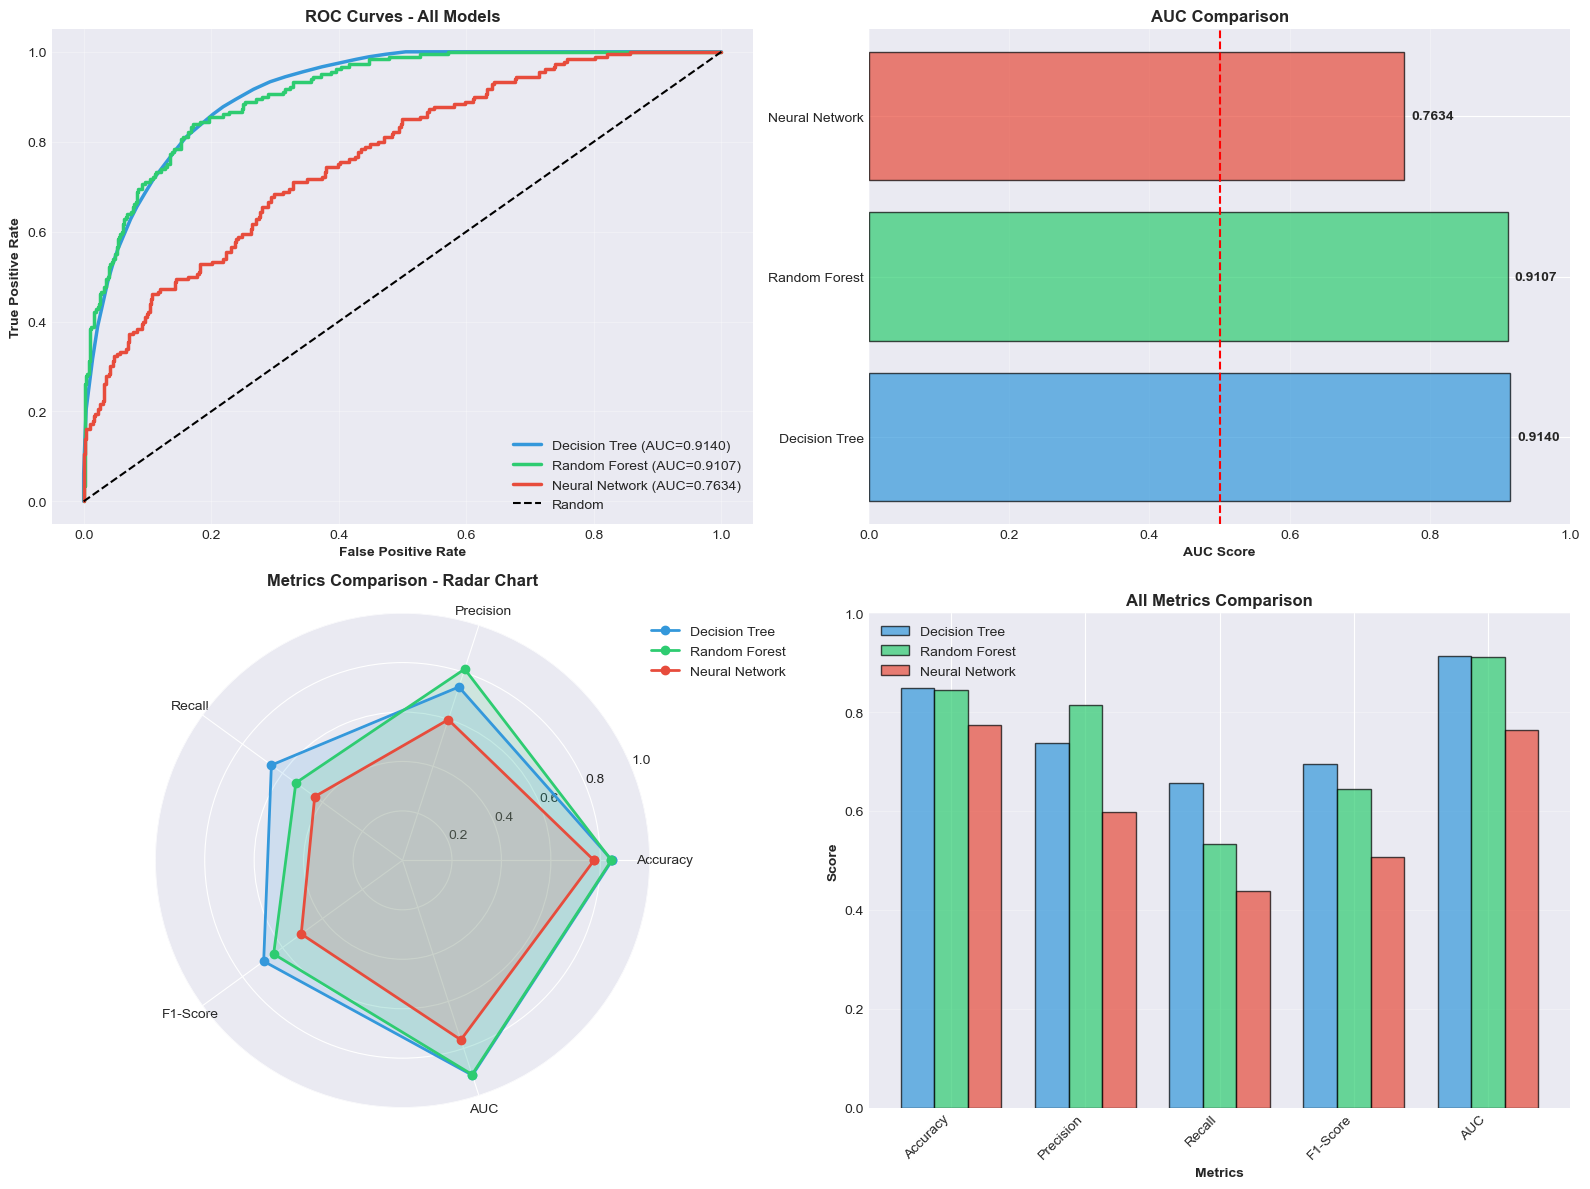

✅ Comparison table saved: reports/model_comparison_dt_rf_nn.csv


In [25]:
# ============================================================================
# COMPREHENSIVE COMPARISON: ALL THREE MODELS
# ============================================================================

print("\n" + "="*80)
print("🏆 COMPREHENSIVE MODEL COMPARISON")
print("="*80)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Neural Network'],
    'Accuracy': [accuracy_dt, accuracy_rf, accuracy_nn],
    'Precision': [precision_dt, precision_rf, precision_nn],
    'Recall': [recall_dt, recall_rf, recall_nn],
    'F1-Score': [f1_dt, f1_rf, f1_nn],
    'AUC': [auc_dt, auc_rf, auc_nn]
})

# Sort by AUC
comparison_df = comparison_df.sort_values('AUC', ascending=False).reset_index(drop=True)
comparison_df['Rank'] = range(1, len(comparison_df) + 1)

print("\n📊 PERFORMANCE SUMMARY TABLE:")
print("="*80)
print(comparison_df.to_string(index=False))

# Identify best model
best_model = comparison_df.iloc[0]
print("\n" + "="*80)
print("🏆 BEST PERFORMING MODEL")
print("="*80)
print(f"   Model:     {best_model['Model']}")
print(f"   AUC:       {best_model['AUC']:.4f}")
print(f"   Accuracy:  {best_model['Accuracy']:.4f}")
print(f"   Precision: {best_model['Precision']:.4f}")
print(f"   Recall:    {best_model['Recall']:.4f}")
print(f"   F1-Score:  {best_model['F1-Score']:.4f}")

# Create comprehensive visualization
fig = plt.figure(figsize=(16, 12))

# 1. ROC Curves - All Models
ax1 = plt.subplot(2, 2, 1)
ax1.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC={auc_dt:.4f})', 
         linewidth=2.5, color='#3498db')
ax1.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.4f})', 
         linewidth=2.5, color='#2ecc71')
ax1.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC={auc_nn:.4f})', 
         linewidth=2.5, color='#e74c3c')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random')
ax1.set_xlabel('False Positive Rate', fontweight='bold')
ax1.set_ylabel('True Positive Rate', fontweight='bold')
ax1.set_title('ROC Curves - All Models', fontweight='bold', fontsize=12)
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)

# 2. AUC Comparison Bar Chart
ax2 = plt.subplot(2, 2, 2)
colors_bar = ['#3498db', '#2ecc71', '#e74c3c']
bars = ax2.barh(comparison_df['Model'], comparison_df['AUC'], 
                color=colors_bar, alpha=0.7, edgecolor='black')
ax2.set_xlabel('AUC Score', fontweight='bold')
ax2.set_title('AUC Comparison', fontweight='bold', fontsize=12)
ax2.set_xlim([0, 1])
ax2.axvline(x=0.5, color='red', linestyle='--', linewidth=1.5, label='Baseline')
ax2.grid(axis='x', alpha=0.3)
for i, v in enumerate(comparison_df['AUC']):
    ax2.text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')

# 3. Metrics Comparison - Radar/Spider Chart
ax3 = plt.subplot(2, 2, 3, projection='polar')
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

for i, row in comparison_df.iterrows():
    values = [row['Accuracy'], row['Precision'], row['Recall'], 
              row['F1-Score'], row['AUC']]
    values += values[:1]
    ax3.plot(angles, values, 'o-', linewidth=2, label=row['Model'], 
             color=colors_bar[i])
    ax3.fill(angles, values, alpha=0.15, color=colors_bar[i])

ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(categories)
ax3.set_ylim(0, 1)
ax3.set_title('Metrics Comparison - Radar Chart', fontweight='bold', 
              fontsize=12, pad=20)
ax3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax3.grid(True)

# 4. Grouped Bar Chart for All Metrics
ax4 = plt.subplot(2, 2, 4)
x = np.arange(len(categories))
width = 0.25

for i, row in comparison_df.iterrows():
    values = [row['Accuracy'], row['Precision'], row['Recall'], 
              row['F1-Score'], row['AUC']]
    ax4.bar(x + i*width, values, width, label=row['Model'], 
            color=colors_bar[i], alpha=0.7, edgecolor='black')

ax4.set_xlabel('Metrics', fontweight='bold')
ax4.set_ylabel('Score', fontweight='bold')
ax4.set_title('All Metrics Comparison', fontweight='bold', fontsize=12)
ax4.set_xticks(x + width)
ax4.set_xticklabels(categories, rotation=45, ha='right')
ax4.set_ylim([0, 1])
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('reports/figures/15_comprehensive_model_comparison.png', dpi=300, bbox_inches='tight')
print("\n✅ Comprehensive comparison saved: reports/figures/15_comprehensive_model_comparison.png")
plt.show()

# Save comparison table
comparison_df.to_csv('reports/model_comparison_dt_rf_nn.csv', index=False)
print("✅ Comparison table saved: reports/model_comparison_dt_rf_nn.csv")

### STEP 9: Cross-Validation for More Realistic Estimates


🔄 BONUS: Cross-Validation Analysis (More Realistic)

ℹ️  Using 5-Fold Cross-Validation to estimate true performance
   (This provides more realistic estimates than training data evaluation)

🌳 Decision Tree Cross-Validation...
   AUC: 0.7226 (+/- 0.0276)
🌲 Random Forest Cross-Validation...
   AUC: 0.8040 (+/- 0.0399)
🧠 Neural Network Cross-Validation...
   AUC: 0.7967 (+/- 0.0893)

📊 TRAINING vs CROSS-VALIDATION COMPARISON

         Model  Training AUC  CV AUC (Mean)  CV Std Dev  Overfitting Gap
 Decision Tree      0.914032       0.722587    0.027628         0.191446
 Random Forest      0.910736       0.803994    0.039904         0.106741
Neural Network      0.763408       0.796717    0.089337        -0.033308

💡 INTERPRETATION:
   • Training AUC: Performance on full training data (overly optimistic)
   • CV AUC: Average performance on held-out folds (realistic estimate)
   • Overfitting Gap: Difference shows how much model memorizes vs generalizes
   • Larger gap = More overfitting


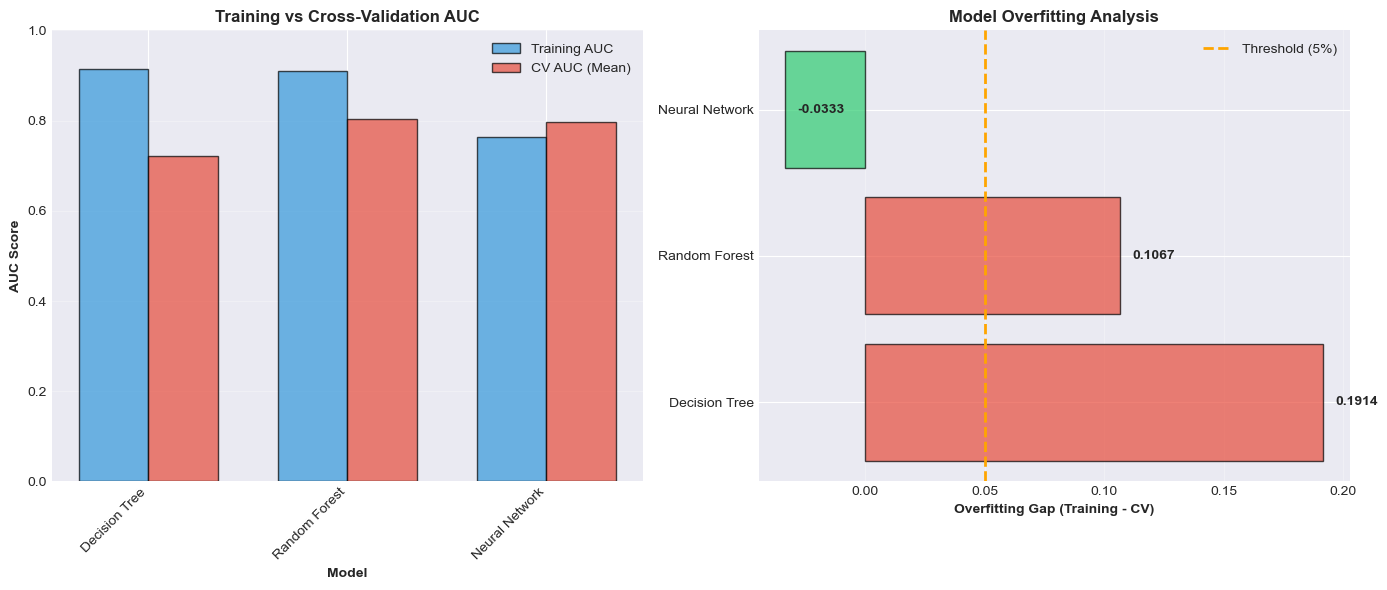

In [26]:
# ============================================================================
# BONUS: CROSS-VALIDATION FOR REALISTIC PERFORMANCE ESTIMATES
# ============================================================================

print("\n" + "="*80)
print("🔄 BONUS: Cross-Validation Analysis (More Realistic)")
print("="*80)
print("\nℹ️  Using 5-Fold Cross-Validation to estimate true performance")
print("   (This provides more realistic estimates than training data evaluation)\n")

# Set up cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Decision Tree CV
print("🌳 Decision Tree Cross-Validation...")
dt_cv_scores = cross_val_score(dt_classifier, X, y, cv=cv, scoring='roc_auc')
dt_cv_mean = dt_cv_scores.mean()
dt_cv_std = dt_cv_scores.std()
print(f"   AUC: {dt_cv_mean:.4f} (+/- {dt_cv_std:.4f})")

# Random Forest CV
print("🌲 Random Forest Cross-Validation...")
rf_cv_scores = cross_val_score(rf_classifier, X, y, cv=cv, scoring='roc_auc')
rf_cv_mean = rf_cv_scores.mean()
rf_cv_std = rf_cv_scores.std()
print(f"   AUC: {rf_cv_mean:.4f} (+/- {rf_cv_std:.4f})")

# Neural Network CV
print("🧠 Neural Network Cross-Validation...")
nn_cv_scores = cross_val_score(nn_classifier, X_scaled, y, cv=cv, scoring='roc_auc')
nn_cv_mean = nn_cv_scores.mean()
nn_cv_std = nn_cv_scores.std()
print(f"   AUC: {nn_cv_mean:.4f} (+/- {nn_cv_std:.4f})")

# Comparison
print("\n" + "="*80)
print("📊 TRAINING vs CROSS-VALIDATION COMPARISON")
print("="*80)

cv_comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Neural Network'],
    'Training AUC': [auc_dt, auc_rf, auc_nn],
    'CV AUC (Mean)': [dt_cv_mean, rf_cv_mean, nn_cv_mean],
    'CV Std Dev': [dt_cv_std, rf_cv_std, nn_cv_std],
    'Overfitting Gap': [auc_dt - dt_cv_mean, auc_rf - rf_cv_mean, auc_nn - nn_cv_mean]
})

print("\n" + cv_comparison.to_string(index=False))

print("\n💡 INTERPRETATION:")
print("   • Training AUC: Performance on full training data (overly optimistic)")
print("   • CV AUC: Average performance on held-out folds (realistic estimate)")
print("   • Overfitting Gap: Difference shows how much model memorizes vs generalizes")
print("   • Larger gap = More overfitting")

# Visualize comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Training vs CV AUC
x_pos = np.arange(len(cv_comparison))
width = 0.35

ax1.bar(x_pos - width/2, cv_comparison['Training AUC'], width, 
        label='Training AUC', color='#3498db', alpha=0.7, edgecolor='black')
ax1.bar(x_pos + width/2, cv_comparison['CV AUC (Mean)'], width,
        label='CV AUC (Mean)', color='#e74c3c', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Model', fontweight='bold')
ax1.set_ylabel('AUC Score', fontweight='bold')
ax1.set_title('Training vs Cross-Validation AUC', fontweight='bold', fontsize=12)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(cv_comparison['Model'], rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1])

# Overfitting Gap
colors_gap = ['#e74c3c' if gap > 0.05 else '#2ecc71' for gap in cv_comparison['Overfitting Gap']]
ax2.barh(cv_comparison['Model'], cv_comparison['Overfitting Gap'], 
         color=colors_gap, alpha=0.7, edgecolor='black')
ax2.set_xlabel('Overfitting Gap (Training - CV)', fontweight='bold')
ax2.set_title('Model Overfitting Analysis', fontweight='bold', fontsize=12)
ax2.axvline(x=0.05, color='orange', linestyle='--', linewidth=2, label='Threshold (5%)')
ax2.legend()
ax2.grid(axis='x', alpha=0.3)
for i, v in enumerate(cv_comparison['Overfitting Gap']):
    ax2.text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('reports/figures/16_cross_validation_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

